# Step 5.1 - Clustering: K-Means

**Goal:** Partition the 730 laws into *k* thematic clusters using K-Means on both feature representations.

**Two values of k are evaluated:**
- **Data-driven k** (Elbow + Silhouette optimum): what does the algorithm discover without guidance?
- **k=9** (external validation): does unsupervised clustering reproduce the 9 official SGBS Hauptgruppen?

| HG | Sachgebiet |
|----|------------|
| 1  | Staatsrechtliche Grundlagen / Organisation |
| 2  | Zivilrecht / Strafrecht / Rechtspflege |
| 3  | Gesundheit |
| 4  | Erziehung, Wissenschaft und Kulturpflege |
| 5  | Polizei / Militaer / Feuerwehr |
| 6  | Finanzen / Liegenschaften / Monopole |
| 7  | Bau / Energie / Umwelt |
| 8  | Arbeit / Soziale Sicherheit |
| 9  | Wirtschaft und Verkehr |

## 1. Setup

In [1]:
import numpy as np
import scipy.sparse as sp
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import os

PCA_TFIDF_PATH     = "../data/processed/pca_tfidf_50.npy"
PCA_W2V_PATH       = "../data/processed/pca_w2v_50.npy"
TFIDF_MATRIX_PATH  = "../data/processed/tfidf_matrix.npz"
TFIDF_VOCAB_PATH   = "../data/processed/tfidf_vocab.csv"
CLEAN_DATA_PATH    = "../data/processed/sgbs_clean.csv"

LABELS_TFIDF_9_PATH  = "../data/processed/kmeans_labels_tfidf_k9.npy"
LABELS_W2V_9_PATH    = "../data/processed/kmeans_labels_w2v_k9.npy"
RESULTS_PATH         = "../data/processed/kmeans_results.csv"

os.makedirs("../data/processed", exist_ok=True)
os.makedirs("../report/figures", exist_ok=True)

SEED       = 42
K_OFFICIAL = 9

HAUPTGRUPPEN = {
    '1': 'Staatsrecht/Org.',
    '2': 'Zivilrecht/Strafrecht',
    '3': 'Gesundheit',
    '4': 'Erziehung/Wiss.',
    '5': 'Polizei/Militaer',
    '6': 'Finanzen/Lieg.',
    '7': 'Bau/Energie/Umwelt',
    '8': 'Arbeit/Soziales',
    '9': 'Wirtschaft/Verkehr',
}

# Outliers already removed in 03_2
X_tfidf = np.load(PCA_TFIDF_PATH)
X_w2v   = np.load(PCA_W2V_PATH)

df = pd.read_csv(CLEAN_DATA_PATH)
df['hauptgruppe'] = df['systematic_number'].astype(str).str[0].apply(
    lambda x: x if x in HAUPTGRUPPEN else 'S'
)

vocab       = pd.read_csv(TFIDF_VOCAB_PATH)['token'].tolist()
X_tfidf_raw = sp.load_npz(TFIDF_MATRIX_PATH).tocsr()

print(f"TF-IDF PCA:   {X_tfidf.shape}")
print(f"Word2Vec PCA: {X_w2v.shape}")
print(f"Docs:         {len(df)}")
print(f"Vocabulary:   {len(vocab)} terms")

TF-IDF PCA:   (730, 50)
Word2Vec PCA: (730, 50)
Docs:         730
Vocabulary:   5000 terms


## 2. Choose k - Elbow + Silhouette (k = 2..20)

In [2]:
K_RANGE = range(2, 21)

def evaluate_k(X, k_range):
    inertias, silhouettes = [], []
    for k in k_range:
        km  = KMeans(n_clusters=k, random_state=SEED, n_init=10)
        lbl = km.fit_predict(X)
        inertias.append(km.inertia_)
        sil = silhouette_score(X, lbl, sample_size=min(500, len(X)), random_state=SEED)
        silhouettes.append(sil)
        print(f"  k={k:2d}  inertia={km.inertia_:,.0f}  silhouette={sil:.4f}")
    return inertias, silhouettes

print("=== TF-IDF ===")
inertias_tfidf, sils_tfidf = evaluate_k(X_tfidf, K_RANGE)

print("\n=== Word2Vec ===")
inertias_w2v, sils_w2v = evaluate_k(X_w2v, K_RANGE)

=== TF-IDF ===
  k= 2  inertia=4,747  silhouette=0.1924
  k= 3  inertia=4,578  silhouette=0.1668
  k= 4  inertia=4,469  silhouette=0.1795
  k= 5  inertia=4,370  silhouette=0.1718
  k= 6  inertia=4,231  silhouette=0.1004
  k= 7  inertia=4,138  silhouette=0.1107
  k= 8  inertia=4,021  silhouette=0.1674
  k= 9  inertia=3,917  silhouette=0.1728
  k=10  inertia=3,869  silhouette=0.1637
  k=11  inertia=3,737  silhouette=0.1656
  k=12  inertia=3,684  silhouette=0.1624
  k=13  inertia=3,612  silhouette=0.1263
  k=14  inertia=3,527  silhouette=0.1523
  k=15  inertia=3,467  silhouette=0.1615
  k=16  inertia=3,392  silhouette=0.1680
  k=17  inertia=3,317  silhouette=0.1551
  k=18  inertia=3,238  silhouette=0.1583
  k=19  inertia=3,208  silhouette=0.1382
  k=20  inertia=3,142  silhouette=0.1762

=== Word2Vec ===
  k= 2  inertia=63,340  silhouette=0.1016
  k= 3  inertia=58,853  silhouette=0.1098
  k= 4  inertia=55,577  silhouette=0.1108
  k= 5  inertia=53,339  silhouette=0.1032
  k= 6  inertia=51,3

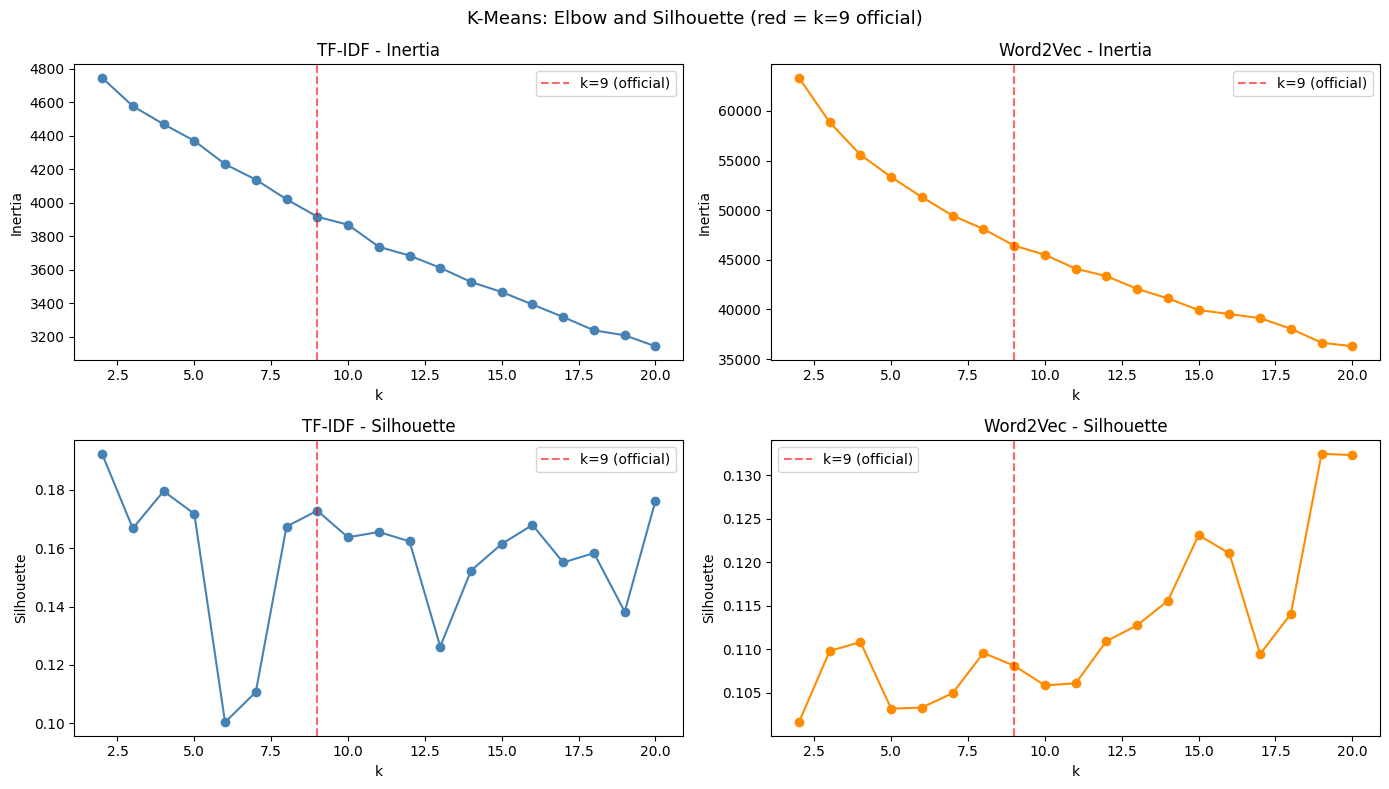

Figure saved.


In [3]:
k_vals = list(K_RANGE)
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for col, (inertias, sils, title) in enumerate([
    (inertias_tfidf, sils_tfidf, "TF-IDF"),
    (inertias_w2v,   sils_w2v,   "Word2Vec"),
]):
    color = "steelblue" if col == 0 else "darkorange"
    for row, (vals, ylabel) in enumerate([(inertias, "Inertia"), (sils, "Silhouette")]):
        axes[row, col].plot(k_vals, vals, marker="o", color=color)
        axes[row, col].axvline(K_OFFICIAL, color="red", linestyle="--",
                               alpha=0.6, label=f"k={K_OFFICIAL} (official)")
        axes[row, col].set_title(f"{title} - {ylabel}")
        axes[row, col].set_xlabel("k")
        axes[row, col].set_ylabel(ylabel)
        axes[row, col].legend()

plt.suptitle("K-Means: Elbow and Silhouette (red = k=9 official)", fontsize=13)
plt.tight_layout()
plt.savefig("../report/figures/05_1_kmeans_selection.png", dpi=150)
plt.show()
print("Figure saved.")

## 3. Select k and Run Final K-Means

In [4]:
K_AUTO_TFIDF = sils_tfidf.index(max(sils_tfidf)) + 2
K_AUTO_W2V   = sils_w2v.index(max(sils_w2v)) + 2

print(f"Best silhouette k: TF-IDF={K_AUTO_TFIDF} ({max(sils_tfidf):.4f}), "
      f"Word2Vec={K_AUTO_W2V} ({max(sils_w2v):.4f})")
print(f"Silhouette at k=9: TF-IDF={sils_tfidf[K_OFFICIAL-2]:.4f}, "
      f"Word2Vec={sils_w2v[K_OFFICIAL-2]:.4f}")
print()

km_tfidf     = KMeans(n_clusters=K_AUTO_TFIDF, random_state=SEED, n_init=20)
labels_tfidf = km_tfidf.fit_predict(X_tfidf)

km_w2v       = KMeans(n_clusters=K_AUTO_W2V, random_state=SEED, n_init=20)
labels_w2v   = km_w2v.fit_predict(X_w2v)

km_tfidf_9     = KMeans(n_clusters=K_OFFICIAL, random_state=SEED, n_init=20)
labels_tfidf_9 = km_tfidf_9.fit_predict(X_tfidf)

km_w2v_9       = KMeans(n_clusters=K_OFFICIAL, random_state=SEED, n_init=20)
labels_w2v_9   = km_w2v_9.fit_predict(X_w2v)

for name, labels, X in [
    (f"TF-IDF auto (k={K_AUTO_TFIDF})",  labels_tfidf,   X_tfidf),
    (f"Word2Vec auto (k={K_AUTO_W2V})",   labels_w2v,     X_w2v),
    (f"TF-IDF k=9",                        labels_tfidf_9, X_tfidf),
    (f"Word2Vec k=9",                      labels_w2v_9,   X_w2v),
]:
    sil = silhouette_score(X, labels)
    print(f"{name:30s} silhouette={sil:.4f}")

Best silhouette k: TF-IDF=2 (0.1924), Word2Vec=19 (0.1325)
Silhouette at k=9: TF-IDF=0.1728, Word2Vec=0.1081

TF-IDF auto (k=2)              silhouette=0.2231
Word2Vec auto (k=19)           silhouette=0.1360
TF-IDF k=9                     silhouette=0.1848
Word2Vec k=9                   silhouette=0.1123


## 4. Cluster Size Distribution

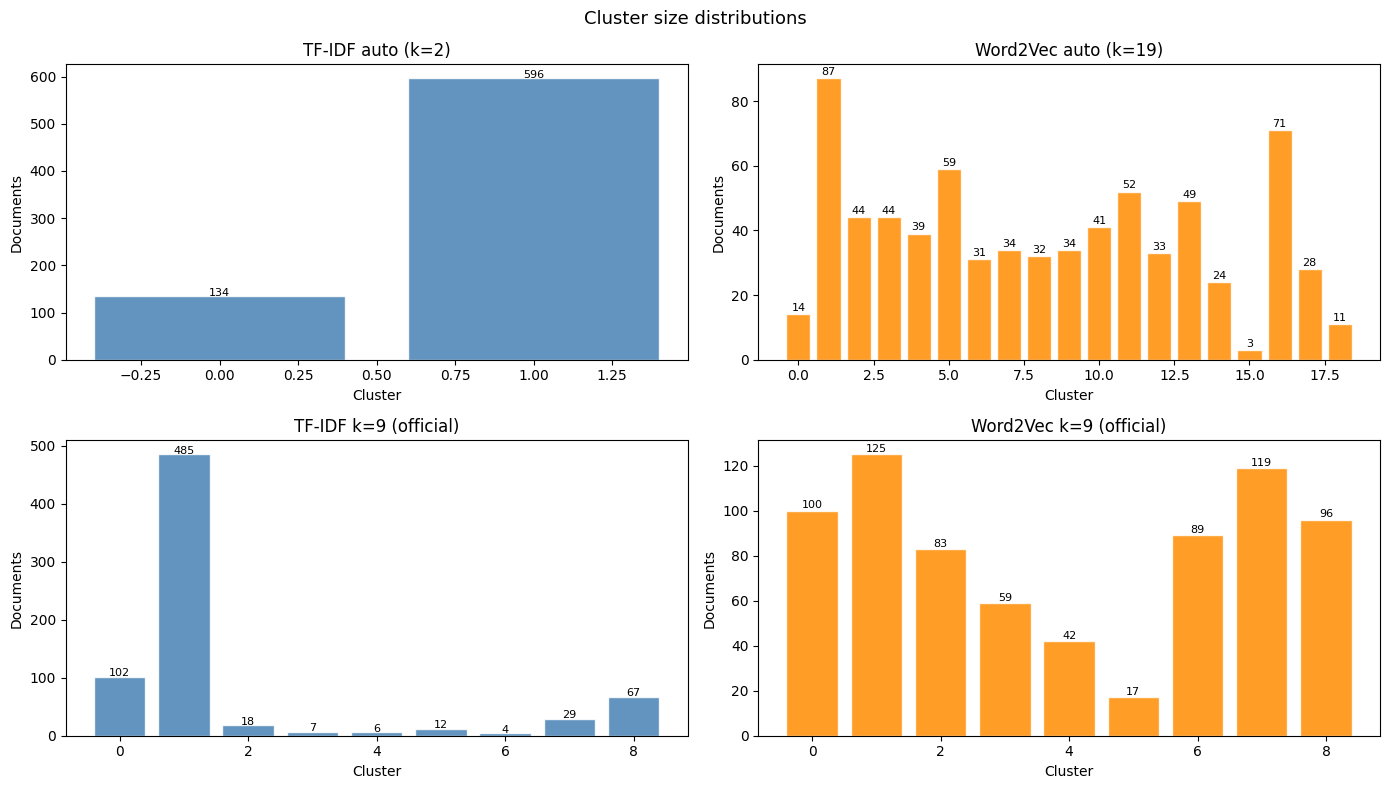

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
configs = [
    (axes[0,0], labels_tfidf,   f"TF-IDF auto (k={K_AUTO_TFIDF})",  "steelblue"),
    (axes[0,1], labels_w2v,     f"Word2Vec auto (k={K_AUTO_W2V})",   "darkorange"),
    (axes[1,0], labels_tfidf_9, "TF-IDF k=9 (official)",             "steelblue"),
    (axes[1,1], labels_w2v_9,   "Word2Vec k=9 (official)",            "darkorange"),
]
for ax, labels, title, color in configs:
    counts = pd.Series(labels).value_counts().sort_index()
    ax.bar(counts.index, counts.values, color=color, edgecolor="white", alpha=0.85)
    ax.set_title(title)
    ax.set_xlabel("Cluster")
    ax.set_ylabel("Documents")
    for i, v in zip(counts.index, counts.values):
        ax.text(i, v + 1, str(v), ha="center", fontsize=8)
plt.suptitle("Cluster size distributions", fontsize=13)
plt.tight_layout()
plt.savefig("../report/figures/05_1_kmeans_sizes.png", dpi=150)
plt.show()

## 5. Top Terms per Cluster - TF-IDF

For each cluster, compute the mean TF-IDF weight across member documents and show the top 10 terms.

In [6]:
TOP_N = 10

def top_tfidf_terms(labels, k, X_raw, vocab, top_n=10):
    for cid in range(k):
        mask = labels == cid
        mean_w = np.asarray(X_raw[mask].mean(axis=0)).flatten()
        top_idx = mean_w.argsort()[::-1][:top_n]
        top_str = ", ".join(f"{vocab[i]} ({mean_w[i]:.3f})" for i in top_idx)
        print(f"  C{cid:2d} ({mask.sum():3d} docs): {top_str}")

print(f"=== TF-IDF auto (k={K_AUTO_TFIDF}) ===")
top_tfidf_terms(labels_tfidf, K_AUTO_TFIDF, X_tfidf_raw, vocab, TOP_N)

print(f"\n=== TF-IDF k=9 ===")
top_tfidf_terms(labels_tfidf_9, K_OFFICIAL, X_tfidf_raw, vocab, TOP_N)

=== TF-IDF auto (k=2) ===
  C 0 (134 docs): bau (0.027), anlage (0.024), auflage (0.022), einrichtung (0.020), beitrag (0.020), schutz (0.019), raum (0.018), sicherheit (0.017), unternehmen (0.017), arbeit (0.017)
  C 1 (596 docs): beitrag (0.016), stadt (0.013), wirtschaft (0.013), schule (0.012), entschädigung (0.012), zusammenarbeit (0.012), kind (0.012), arbeit (0.012), information (0.011), mitarbeiter (0.011)

=== TF-IDF k=9 ===
  C 0 (102 docs): bau (0.034), beitrag (0.027), anlage (0.027), auflage (0.026), gebiet (0.021), einrichtung (0.020), schutz (0.020), fachstelle (0.019), tier (0.018), raum (0.018)
  C 1 (485 docs): beitrag (0.017), stadt (0.015), wirtschaft (0.013), zusammenarbeit (0.013), bau (0.012), kind (0.012), gebiet (0.012), entschädigung (0.012), mitarbeiter (0.012), anlage (0.011)
  C 2 ( 18 docs): note (0.108), zulassung (0.082), wiederholen (0.071), wiederholung (0.070), expertin (0.068), fach (0.067), kandidat (0.067), mündlich (0.065), experte (0.064), bewert

## 6. Extern: k=9 Cluster vs. offizielle Hauptgruppen

In [ ]:
df['cluster_tfidf']   = labels_tfidf
df['cluster_w2v']     = labels_w2v
df['cluster_tfidf_9'] = labels_tfidf_9
df['cluster_w2v_9']   = labels_w2v_9

hg_order = [str(i) for i in range(1, 10) if str(i) in df['hauptgruppe'].unique()]
if 'S' in df['hauptgruppe'].unique():
    hg_order.append('S')

print("Legende: " + " | ".join(f"{k}={v}" for k, v in HAUPTGRUPPEN.items()))

print("\n=== TF-IDF k=9: Cluster x Hauptgruppe ===")
ct_t9 = pd.crosstab(df['cluster_tfidf_9'], df['hauptgruppe'])[hg_order]
print(ct_t9.to_string())

print("\n=== Word2Vec k=9: Cluster x Hauptgruppe ===")
ct_w9 = pd.crosstab(df['cluster_w2v_9'], df['hauptgruppe'])[hg_order]
print(ct_w9.to_string())

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, ct, title, cmap in [
    (axes[0], ct_t9, "TF-IDF k=9",   "Blues"),
    (axes[1], ct_w9, "Word2Vec k=9",  "Oranges"),
]:
    ct_norm = ct.div(ct.sum(axis=1), axis=0)
    im = ax.imshow(ct_norm.values, cmap=cmap, aspect="auto", vmin=0, vmax=1)
    ax.set_xticks(range(len(ct.columns)))
    ax.set_xticklabels(ct.columns, rotation=45, ha="right")
    ax.set_yticks(range(len(ct.index)))
    ax.set_yticklabels([f"C{i}" for i in ct.index])
    ax.set_xlabel("Hauptgruppe")
    ax.set_ylabel("K-Means Cluster")
    ax.set_title(f"{title} - Cluster composition (row-normalised)")
    for r in range(len(ct.index)):
        for c in range(len(ct.columns)):
            val = ct.values[r, c]
            if val > 0:
                ax.text(c, r, str(val), ha="center", va="center",
                        fontsize=7,
                        color="white" if ct_norm.values[r, c] > 0.5 else "black")
    plt.colorbar(im, ax=ax, fraction=0.04)

plt.suptitle("K-Means k=9 vs. offizielle SGBS Hauptgruppen", fontsize=13)
plt.tight_layout()
plt.savefig("../report/figures/05_1_kmeans_vs_hauptgruppen.png", dpi=150)
plt.show()
print("Figure saved.")

## 7. Persist

In [ ]:
np.save(LABELS_TFIDF_9_PATH, labels_tfidf_9)
np.save(LABELS_W2V_9_PATH,   labels_w2v_9)
print("Saved cluster labels (k=9 for TF-IDF and Word2Vec).")

df[[
    "cluster_tfidf", "cluster_w2v", "cluster_tfidf_9", "cluster_w2v_9"
]].to_csv(RESULTS_PATH, index=False)
print(f"Saved results CSV to {RESULTS_PATH}")